# When compute changes its thermal behavior
**Executed exploratory study — Marconi100 ExaData, racks 0 and 5.**

Question: can an interpretable conditional model distinguish ordinary temperature
changes associated with power/inlet conditions from unusual thermal episodes?
We compare it with PCA and a small autoencoder, and examine persistent changes.
This is retrospective exploration with a chronological holdout, not a validated fault detector.

Sources: [paper](https://www.nature.com/articles/s41597-023-02174-3),
[15-minute dataset, CC BY 4.0](https://doi.org/10.5281/zenodo.7541722),
[publisher metadata](https://gitlab.com/ecs-lab/exadata/-/tree/main/documentation).
Credit: Borghesi and coauthors / CINECA / University of Bologna.
The downloaded publisher manifest and sensor documentation accompany this notebook.

**Scope correction:** these files contain aggregated IPMI sensors, not direct GPU
utilization, job identity, completed work, tariffs or invoices. We can study temperature
conditional on measured power; we cannot demonstrate wasted energy or cost per useful job.

In [1]:
from pathlib import Path
import json, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score, average_precision_score, roc_auc_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
import ruptures as rpt

ROOT = Path.cwd()
if not (ROOT / 'source-manifest.json').exists():
    ROOT = ROOT / 'modeling' / 'marconi100'
DATA, OUT = ROOT / 'data', ROOT / 'results'
OUT.mkdir(exist_ok=True)
SEED = 42
TRAIN_END = pd.Timestamp('2021-09-01', tz='UTC')
CAL_END = pd.Timestamp('2022-01-01', tz='UTC')
START = pd.Timestamp('2021-01-01', tz='UTC')
END = pd.Timestamp('2022-09-29', tz='UTC')
# Eligibility uses only pre-test coverage; no selection by anomaly results.
NODES, eligibility = [], []
for rack in (0, 5):
    available = sorted(int(p.stem) for p in DATA.glob('*.parquet') if p.stem.isdigit() and int(p.stem)//20 == rack)
    eligible = []
    for node in available:
        q = pd.read_parquet(DATA/f'{node}.parquet', columns=['timestamp','value','total_power_avg','ambient_avg','p0_power_avg','p1_power_avg']+[f'gpu{k}_core_temp_avg' for k in [0,1,3,4]])
        good = q.drop(columns=['timestamp','value']).notna().all(axis=1) & q.value.eq(0).fillna(False)
        nt = int((good & (q.timestamp >= START) & (q.timestamp < TRAIN_END)).sum())
        nc = int((good & (q.timestamp >= TRAIN_END) & (q.timestamp < CAL_END)).sum())
        eligibility.append({'node':node,'training_complete_state0':nt,'calibration_complete_state0':nc,'eligible':nt>1000 and nc>500})
        if nt>1000 and nc>500: eligible.append(node)
    NODES.extend(np.asarray(eligible)[np.linspace(0,len(eligible)-1,4).astype(int)].tolist())
print('Selected eligible nodes:', NODES)
display(pd.DataFrame(eligibility))
pd.DataFrame(eligibility).to_csv(OUT/'node_eligibility.csv',index=False)

plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': .18, 'font.size': 10, 'savefig.bbox': 'tight'})
COLORS = ['#a34b36', '#326976', '#877646', '#6e598a']

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / f'{name}.png', dpi=160)
    plt.show()

Selected eligible nodes: [2, 9, 14, 19, 103, 109, 112, 118]


,node,training_complete_state0,calibration_complete_state0,eligible
0,2,18033,7960,True
1,3,0,0,False
2,4,0,0,False
3,5,0,0,False
4,6,0,0,False
5,7,19120,7986,True
6,8,19239,7985,True
7,9,19759,7960,True
8,10,19764,7960,True
9,11,19761,7960,True


## 1. Provenance and sampling
Racks 0 and 5 are the two smallest rack archives (excluding `other.tar`), selected
for download size, not representativeness. The initial inspection of rack 0 showed
long periods of stable low power, motivating the second rack. This is a convenience
sample, not a random sample of the 980-node supercomputer.
We audit all files in these two racks and model eight nodes selected evenly by ID after a pre-test coverage check.
Publisher MD5 checks verify archive integrity; per-file SHA256 hashes identify local inputs.

In [2]:
manifest = json.loads((ROOT / 'source-manifest.json').read_text())
archive_audit = []
for rack in (0, 5):
    item = next(f for f in manifest['files'] if f['key'] == f'{rack}.tar')
    with (DATA / item['key']).open('rb') as f:
        digest = 'md5:' + hashlib.file_digest(f, 'md5').hexdigest()
    assert digest == item['checksum']
    archive_audit.append({'rack': rack, 'bytes': item['size'], 'publisher_md5_verified': True})
display(pd.DataFrame(archive_audit))

,rack,bytes,publisher_md5_verified
0,0,269844480,True
1,5,296663040,True


In [3]:
audit, input_hashes = [], []
for path in sorted((p for p in DATA.glob('*.parquet') if p.stem.isdigit()), key=lambda p: int(p.stem)):
    q = pd.read_parquet(path, columns=['timestamp', 'total_power_avg', 'ambient_avg', 'value'])
    q['timestamp'] = pd.to_datetime(q['timestamp'], utc=True)
    expected = int((q.timestamp.max() - q.timestamp.min()) / pd.Timedelta('15min')) + 1
    audit.append({'node': int(path.stem), 'rack': int(path.stem) // 20,
        'rows': len(q), 'start': q.timestamp.min(), 'end': q.timestamp.max(),
        'duplicate_timestamps': int(q.timestamp.duplicated().sum()),
        'absent_grid_pct': 100 * (1 - q.timestamp.nunique() / expected),
        'power_missing_pct': 100 * q.total_power_avg.isna().mean(),
        'label_missing_pct': 100 * q.value.isna().mean(),
        'power_p50_W': q.total_power_avg.median(), 'power_p90_W': q.total_power_avg.quantile(.9)})
    with path.open('rb') as f:
        input_hashes.append({'file': path.name, 'sha256': hashlib.file_digest(f, 'sha256').hexdigest()})
audit = pd.DataFrame(audit)
audit.to_csv(OUT / 'data_quality.csv', index=False)
pd.DataFrame(input_hashes).to_csv(OUT / 'input_hashes.csv', index=False)
display(audit.round(2))
print('Rows across audited source files:', f'{audit.rows.sum():,}')
assert audit.duplicate_timestamps.sum() == 0, 'Resolve duplicates explicitly before continuing.'

/var/folders/3s/7hdlm5wj71v485vs91zc0dyh0000gn/T/ipykernel_44646/3766021631.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(audit.round(2))


,node,rack,rows,start,end,duplicate_timestamps,absent_grid_pct,power_missing_pct,label_missing_pct,power_p50_W,power_p90_W
0,2,0,79989,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,10.73,8.93,11.69,412.00,440.44
1,3,0,72944,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,18.60,9.05,33.32,361.78,373.33
2,4,0,82403,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,8.04,8.74,33.01,439.11,440.89
3,5,0,75952,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,15.24,7.36,27.33,392.44,400.00
4,6,0,82604,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,7.82,7.70,33.18,441.33,449.78
5,7,0,83920,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,6.35,8.07,11.16,421.33,531.56
6,8,0,83922,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,6.35,8.49,11.16,420.44,422.67
7,9,0,83923,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,6.34,8.10,11.16,420.00,420.89
8,10,0,83923,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,6.34,8.10,11.16,435.56,440.00
9,11,0,83919,2020-03-09 12:00:00+00:00,2022-09-28 21:45:00+00:00,0,6.35,8.22,11.16,400.00,400.89


Rows across audited source files: 2,171,312


## 2. What the sensors actually mean
`ambient` is node inlet temperature (°C), `total_power` is total node power (W),
`p0_power` / `p1_power` are CPU-socket power (W), and GPU core temperatures are °C.
Fans are RPM. `gv100card*` has unspecified units in the publisher documentation;
it is deliberately excluded rather than mistaken for GPU utilization or GPU power.

The aggregate `value` label is a Nagios state. We retain raw values; evaluate 0 versus
1/2 as **monitoring-state agreement**, excluding missing/3 (unknown). Nagios covers
network, storage, software and hardware checks, so it is not thermal-fault ground truth.
No alarm labels enter the input features. Training uses state-0 rows as a normal reference;
this is label-informed novelty detection, not fully unsupervised discovery.

In [4]:
gpu_cols = [f'gpu{k}_core_temp_avg' for k in [0, 1, 3, 4]]
fan_cols = [f'fan{k}_{j}_avg' for k in range(4) for j in range(2)]
base_cols = ['timestamp', 'value', 'ambient_avg', 'total_power_avg', 'p0_power_avg', 'p1_power_avg']
frames, column_audit = [], []
for node in NODES:
    raw = pd.read_parquet(DATA / f'{node}.parquet')
    raw['timestamp'] = pd.to_datetime(raw.timestamp, utc=True)
    selected = raw.loc[(raw.timestamp >= START) & (raw.timestamp < END)].copy()
    column_audit.append({'node': node, 'source_columns': len(raw.columns),
        'constant_avg_columns': sum(selected[c].nunique(dropna=True) <= 1 for c in raw if c.endswith('_avg'))})
    d = selected[base_cols + gpu_cols + fan_cols].set_index('timestamp').sort_index()
    # Explicit time grid prevents a lag from crossing an unobserved time interval.
    d = d.reindex(pd.date_range(START, END, freq='15min', inclusive='left', name='timestamp'))
    d['node'], d['rack'] = node, node // 20
    d['gpu_temp'] = d[gpu_cols].mean(axis=1).where(d[gpu_cols].notna().all(axis=1))
    d['gpu_spread'] = (d[gpu_cols].max(axis=1) - d[gpu_cols].min(axis=1)).where(d[gpu_cols].notna().all(axis=1))
    d['fan_rpm'] = d[fan_cols].mean(axis=1).where(d[fan_cols].notna().all(axis=1))
    d['cpu_power'] = d[['p0_power_avg', 'p1_power_avg']].sum(axis=1, min_count=2)
    d['thermal_lift'] = d.gpu_temp - d.ambient_avg
    d['power_lag1'] = d.total_power_avg.shift(1)
    d['power_lag4'] = d.total_power_avg.shift(4)
    d['inlet_lag1'] = d.ambient_avg.shift(1)
    d['split'] = np.where(d.index < TRAIN_END, 'train', np.where(d.index < CAL_END, 'calibration', 'test'))
    frames.append(d.reset_index())
panel = pd.concat(frames, ignore_index=True)
display(pd.DataFrame(column_audit))
display(pd.crosstab(panel.node, panel.value.fillna(-1)).rename(columns={-1:'missing',0:'state 0',1:'state 1',2:'state 2',3:'unknown 3'}))
print('No interpolation or forward filling is used.')

,node,source_columns,constant_avg_columns
0,2,354,4
1,9,354,4
2,14,354,4
3,19,354,4
4,103,354,4
5,109,354,4
6,112,354,4
7,118,354,4


value,missing,state 0,state 2,unknown 3
node,,,,
2,11144,37952,11958,2
9,7231,53340,480,5
14,7231,53334,486,5
19,9192,37814,14045,5
103,4507,55934,577,38
109,4507,55666,845,38
112,4507,55533,977,39
118,4507,55255,1256,38


No interpolation or forward filling is used.


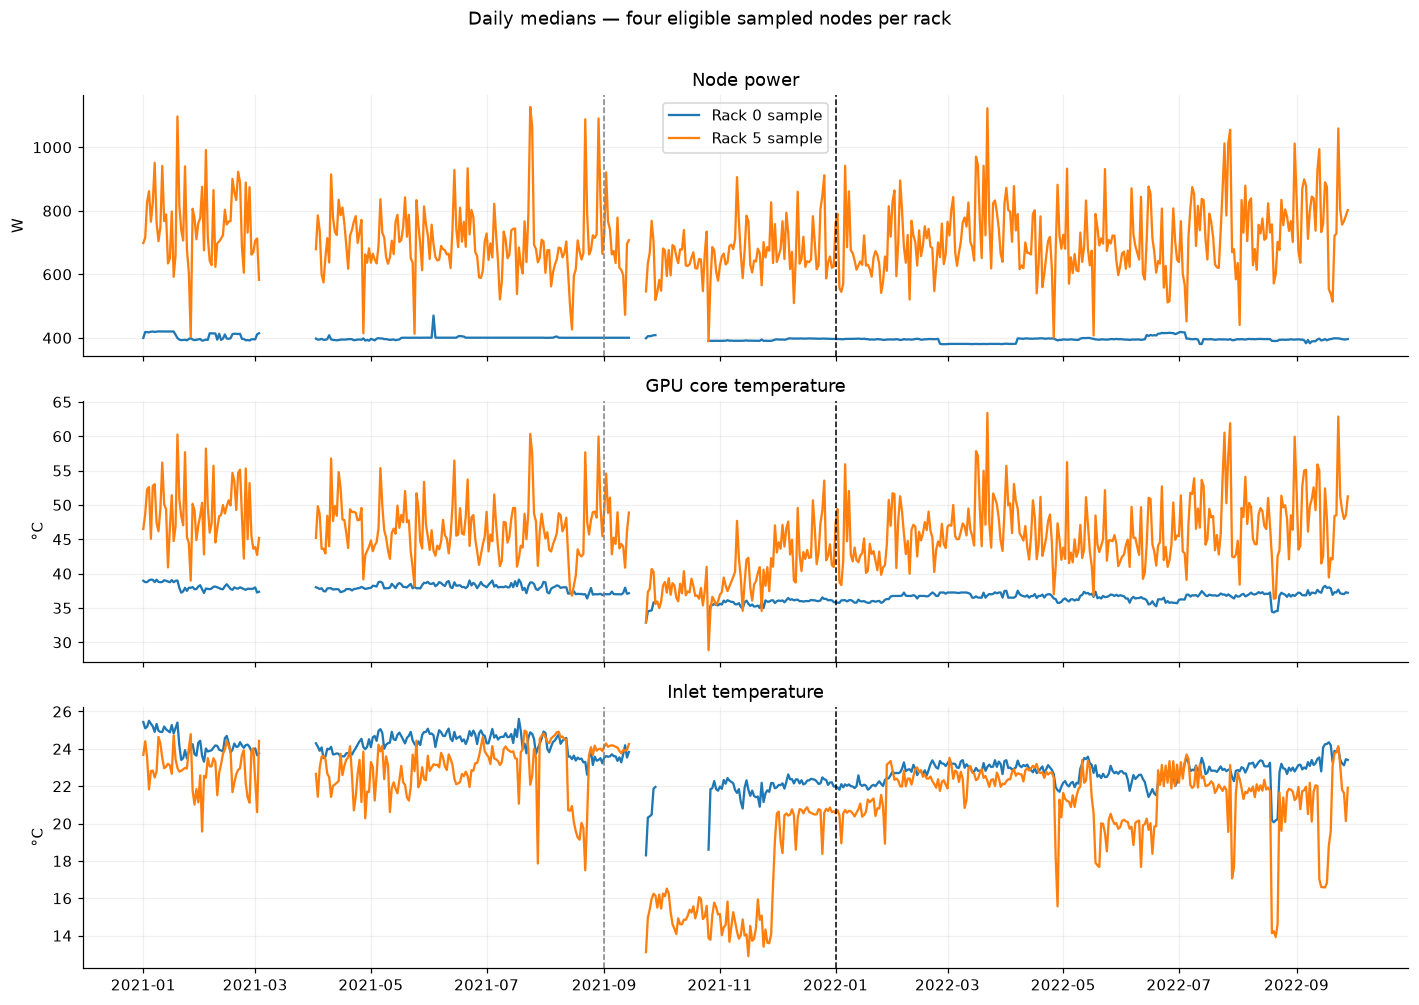

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for rack, g in panel.groupby('rack'):
    daily = g.groupby('timestamp')[['total_power_avg','gpu_temp','ambient_avg']].median().resample('D').median()
    for ax, col in zip(axes, daily.columns):
        ax.plot(daily.index, daily[col], label=f'Rack {rack} sample')
for ax, title, unit in zip(axes, ['Node power', 'GPU core temperature', 'Inlet temperature'], ['W','°C','°C']):
    ax.set(title=title, ylabel=unit)
    ax.axvline(TRAIN_END, color='grey', ls='--', lw=1)
    ax.axvline(CAL_END, color='black', ls='--', lw=1)
axes[0].legend(); fig.suptitle('Daily medians — four eligible sampled nodes per rack', y=1.01)
savefig('01_overview')

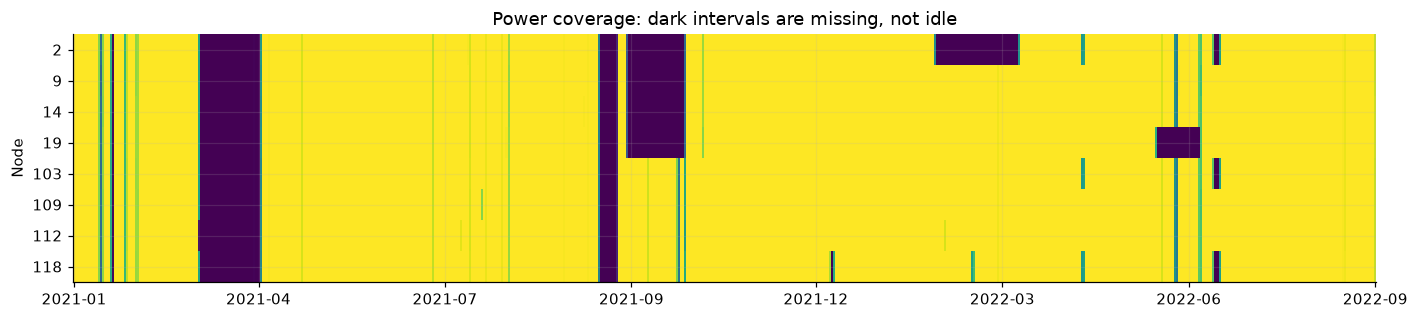

In [6]:
coverage = panel.assign(day=panel.timestamp.dt.floor('D')).groupby(['node','day']).total_power_avg.count().unstack(0) / 96
fig, ax = plt.subplots(figsize=(13, 3))
ax.imshow(coverage.T, aspect='auto', vmin=0, vmax=1, cmap='viridis', interpolation='nearest')
positions = np.linspace(0, len(coverage)-1, 8).astype(int)
ax.set(yticks=range(len(NODES)), yticklabels=coverage.columns,
       xticks=positions, xticklabels=coverage.index[positions].strftime('%Y-%m'),
       title='Power coverage: dark intervals are missing, not idle', ylabel='Node')
savefig('02_coverage')

## 3. Conditional thermal model, with chronological evaluation
Target: mean GPU core temperature minus inlet temperature. Inputs: current total
power, 15-minute and one-hour power lags, CPU power, inlet temperature and inlet lag.
A separate additive cubic-spline ridge regression is fitted per node. Fans and
contemporaneous GPU temperatures are not predictors. No tuning uses the 2022 test data.
This estimates a contemporaneous conditional relationship, not a future forecast.

Training: Jan–Aug 2021, state 0. Calibration: Sep–Dec 2021, state 0.
Test: Jan–Sep 2022. Calibration's 99th percentile of absolute residuals sets each
node's alert threshold. This is an empirical reference band, not a guaranteed
confidence interval under temporal dependence or drift. Complete-case filtering
may remove failures with missing telemetry; coverage is reported separately.

In [7]:
xcols = ['total_power_avg', 'power_lag1', 'power_lag4', 'cpu_power', 'ambient_avg', 'inlet_lag1']
panel['predicted_temp'] = np.nan
panel['thermal_score'] = np.nan
models, fit_metrics, thresholds = {}, [], {}
with threadpool_limits(limits=2):
    for node in NODES:
        valid = (panel.node == node) & panel[xcols + ['gpu_temp','thermal_lift']].notna().all(axis=1)
        train = valid & (panel.split == 'train') & panel.value.eq(0).fillna(False)
        cal = valid & (panel.split == 'calibration') & panel.value.eq(0).fillna(False)
        test = valid & (panel.split == 'test')
        assert train.sum() > 1000 and cal.sum() > 500
        model = make_pipeline(SplineTransformer(n_knots=5, degree=3, extrapolation='linear'),
                              StandardScaler(), Ridge(alpha=100))
        model.fit(panel.loc[train, xcols], panel.loc[train, 'thermal_lift'])
        linear = make_pipeline(StandardScaler(), Ridge(alpha=100)).fit(panel.loc[train,xcols],panel.loc[train,'thermal_lift'])
        linear_pred = linear.predict(panel.loc[test,xcols])+panel.loc[test,'ambient_avg']
        pred = model.predict(panel.loc[valid, xcols]) + panel.loc[valid, 'ambient_avg']
        panel.loc[valid, 'predicted_temp'] = pred
        panel.loc[valid, 'thermal_score'] = np.abs(panel.loc[valid, 'gpu_temp'] - pred)
        thresholds[node] = float(panel.loc[cal, 'thermal_score'].quantile(.99))
        models[node] = model
        fit_metrics.append({'node': node, 'train_rows': int(train.sum()), 'calibration_rows': int(cal.sum()),
            'test_rows': int(test.sum()), 'test_coverage_pct': 100*test.sum()/((panel.node==node)&(panel.split=='test')).sum(),
            'test_MAE_C': mean_absolute_error(panel.loc[test, 'gpu_temp'], panel.loc[test, 'predicted_temp']),
            'linear_test_MAE_C':mean_absolute_error(panel.loc[test,'gpu_temp'],linear_pred),
            'test_R2': r2_score(panel.loc[test, 'gpu_temp'], panel.loc[test, 'predicted_temp']),
            'inlet_plus_train_median_MAE_C': mean_absolute_error(panel.loc[test, 'gpu_temp'],
                panel.loc[test, 'ambient_avg'] + panel.loc[train, 'thermal_lift'].median()),
            'threshold_C': thresholds[node]})
fit_metrics = pd.DataFrame(fit_metrics)
fit_metrics.to_csv(OUT/'thermal_fit.csv', index=False)
panel['thermal_residual'] = panel.gpu_temp - panel.predicted_temp
panel['thermal_threshold'] = panel.node.map(thresholds)
panel['thermal_alert'] = panel.thermal_score > panel.thermal_threshold
display(fit_metrics.round(3))

,node,train_rows,calibration_rows,test_rows,test_coverage_pct,test_MAE_C,linear_test_MAE_C,test_R2,inlet_plus_train_median_MAE_C,threshold_C
0,2,17992,7956,21535,82.776,0.181,0.180,0.972,0.499,1.968
1,9,19655,7956,25811,99.212,0.365,0.204,0.799,0.519,0.657
2,14,19664,7953,25822,99.254,0.177,0.156,0.946,0.443,0.526
3,19,19283,7948,23912,91.913,0.160,0.157,0.883,0.165,0.521
4,103,19551,10556,25469,97.897,0.792,0.733,0.979,5.774,4.540
5,109,19249,10557,25816,99.231,1.294,1.009,0.943,5.401,6.244
6,112,19074,10557,25811,99.212,1.128,1.254,0.968,6.794,5.236
7,118,19398,10556,25244,97.033,0.679,0.777,0.984,6.530,2.824


## 4. PCA and a small autoencoder as alternative anomaly scores
Both reconstruct a 10-dimensional sensor vector. Features are standardized per node
using training state-0 data only. PCA has four components; the autoencoder has
16 → 4 → 16 hidden units and reconstructs the input. Models are pooled across nodes
after scaling. We fit at most 40,000 reproducibly sampled training rows for speed.
These are pointwise multivariate models, not temporal VAEs. A VAE is deferred until
there is evidence that probabilistic latent modeling adds value.

Thresholds use the same calibration period and 99th-percentile rule, separately for
each node. The model families answer different questions: thermal residuals versus
unusual whole-system sensor combinations. Nagios agreement cannot decide which is
best for identifying specifically thermal anomalies.

PCA explained variance: 0.882
AE iterations: 300 | final training loss: 0.0425
Convergence warnings: ["Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet."]


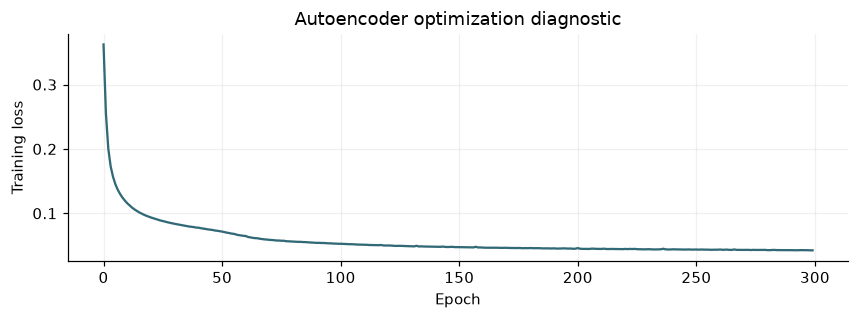

In [8]:
aecols = ['total_power_avg','ambient_avg','cpu_power','fan_rpm','gpu_spread','thermal_lift'] + gpu_cols
panel['pca_score'], panel['ae_score'] = np.nan, np.nan
valid_indices, scaled_parts = [], []
for node in NODES:
    valid = (panel.node == node) & panel[aecols].notna().all(axis=1)
    train = valid & (panel.split == 'train') & panel.value.eq(0).fillna(False)
    scaler = StandardScaler().fit(panel.loc[train, aecols])
    valid_indices.extend(panel.index[valid])
    scaled_parts.append(scaler.transform(panel.loc[valid, aecols]))
idx = np.asarray(valid_indices)
Z = np.vstack(scaled_parts)
train_pos = np.flatnonzero(((panel.loc[idx,'split'] == 'train') & panel.loc[idx,'value'].eq(0).fillna(False)).to_numpy())
rng = np.random.default_rng(SEED)
fit_pos = rng.choice(train_pos, size=min(40000, len(train_pos)), replace=False)
with threadpool_limits(limits=2):
    pca = PCA(n_components=4, random_state=SEED).fit(Z[fit_pos])
    panel.loc[idx, 'pca_score'] = np.mean((Z-pca.inverse_transform(pca.transform(Z)))**2, axis=1)
    ae = MLPRegressor(hidden_layer_sizes=(16,4,16), activation='tanh', max_iter=300,
        batch_size=512, alpha=.01, learning_rate_init=.001, random_state=SEED,
        early_stopping=False, tol=1e-5, n_iter_no_change=15)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        ae.fit(Z[fit_pos], Z[fit_pos])
    panel.loc[idx, 'ae_score'] = np.mean((Z-ae.predict(Z))**2, axis=1)
print('PCA explained variance:', round(pca.explained_variance_ratio_.sum(),3))
print('AE iterations:', ae.n_iter_, '| final training loss:', round(ae.loss_,4))
print('Convergence warnings:', [str(w.message) for w in caught])
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(ae.loss_curve_, color=COLORS[1]); ax.set(xlabel='Epoch',ylabel='Training loss',title='Autoencoder optimization diagnostic')
savefig('03_ae_training')

In [9]:
score_columns = {'Thermal spline': 'thermal_score', 'PCA': 'pca_score', 'Autoencoder': 'ae_score'}
records = []
for name, score in score_columns.items():
    for node in NODES:
        g = panel[panel.node == node]
        cal = g[(g.split == 'calibration') & g.value.eq(0).fillna(False)]
        threshold = cal[score].quantile(.99)
        panel.loc[g.index, score+'_threshold'] = threshold
        # Same rows across models for a fair point-level comparison.
        test = g[(g.split == 'test') & g.value.isin([0,1,2]) & g[list(score_columns.values())].notna().all(axis=1)]
        y = test.value.isin([1,2]).astype(int)
        alarm = test[score] > threshold
        tp, fp = int((alarm & y.eq(1)).sum()), int((alarm & y.eq(0)).sum())
        records.append({'model':name, 'node':node, 'n':len(test), 'state12_rows':int(y.sum()),
            'prevalence':y.mean(), 'ROC_AUC':roc_auc_score(y,test[score]) if y.nunique()==2 else np.nan,
            'average_precision':average_precision_score(y,test[score]) if y.sum() else np.nan,
            'precision':tp/(tp+fp) if tp+fp else np.nan,
            'recall':tp/y.sum() if y.sum() else np.nan,
            'state0_alert_rate':fp/(y==0).sum(), 'alert_rows':int(alarm.sum())})
metrics = pd.DataFrame(records)
metrics.to_csv(OUT/'model_comparison.csv',index=False)
display(metrics.round(4))
display(metrics.groupby('model')[['ROC_AUC','average_precision','precision','recall','state0_alert_rate']].mean().round(4))

,model,node,n,state12_rows,prevalence,ROC_AUC,average_precision,precision,recall,state0_alert_rate,alert_rows
0,Thermal spline,2,21498,9636,0.4482,0.4452,0.3993,0.0000,0.0000,0.0008,9
1,Thermal spline,9,25752,165,0.0064,0.6013,0.0103,0.0230,0.1818,0.0498,1305
2,Thermal spline,14,25762,178,0.0069,0.3610,0.0095,0.0438,0.0955,0.0145,388
3,Thermal spline,19,23855,13374,0.5606,0.5932,0.6336,0.4182,0.0034,0.0061,110
4,Thermal spline,103,25409,156,0.0061,0.4807,0.0055,0.0000,0.0000,0.0017,43
5,Thermal spline,109,25756,120,0.0047,0.3791,0.0207,0.0667,0.0167,0.0011,30
6,Thermal spline,112,25750,123,0.0048,0.3523,0.0045,0.0045,0.0081,0.0085,220
7,Thermal spline,118,25184,460,0.0183,0.3118,0.0120,0.0044,0.0065,0.0275,683
8,PCA,2,21498,9636,0.4482,0.4836,0.4297,0.0455,0.0006,0.0106,132
9,PCA,9,25752,165,0.0064,0.6231,0.0108,0.0153,0.0121,0.0050,131


,ROC_AUC,average_precision,precision,recall,state0_alert_rate
model,,,,,
Autoencoder,0.4187,0.1371,0.1075,0.0063,0.0099
PCA,0.3787,0.1155,0.0208,0.0047,0.0105
Thermal spline,0.4406,0.1369,0.0701,0.0390,0.0138


**Reading these metrics:** the no-skill average-precision reference is the positive
prevalence, not 0.5. State-0 alerts may be genuine physical departures unrecorded by
Nagios, and state-1/2 events may have no thermal signature. Metrics are descriptive
point-level agreement, without point adjustment. Adjacent rows are dependent;
they must not be treated as independent fault examples or independent confidence samples.

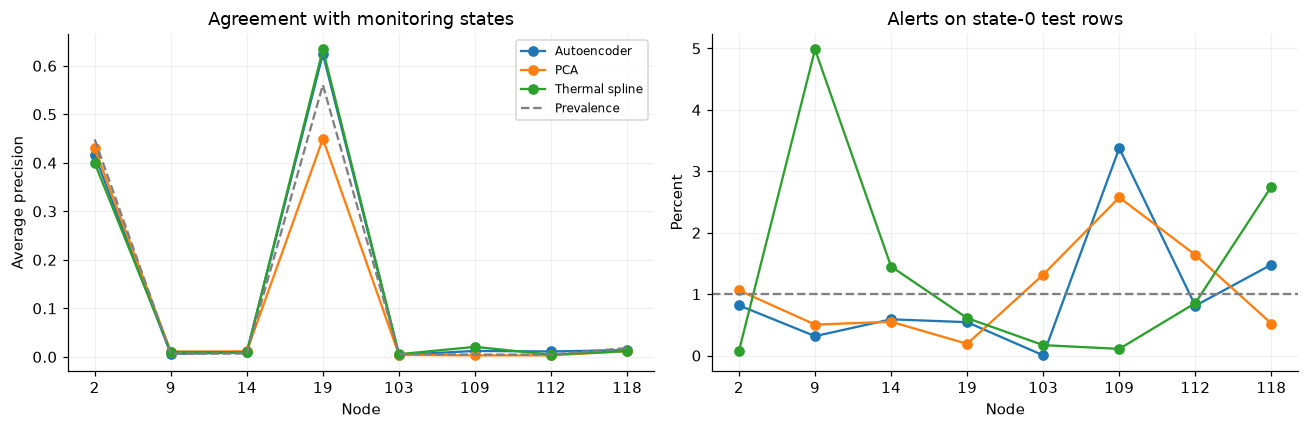

In [10]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
for name, g in metrics.groupby('model'):
    axes[0].plot(g.node.astype(str),g.average_precision,marker='o',label=name)
    axes[1].plot(g.node.astype(str),g.state0_alert_rate*100,marker='o',label=name)
axes[0].plot(metrics[metrics.model=='PCA'].node.astype(str), metrics[metrics.model=='PCA'].prevalence,ls='--',color='grey',label='Prevalence')
axes[0].set(title='Agreement with monitoring states',ylabel='Average precision',xlabel='Node')
axes[1].set(title='Alerts on state-0 test rows',ylabel='Percent',xlabel='Node')
axes[0].legend(fontsize=8); axes[1].axhline(1,color='grey',ls='--')
savefig('04_model_comparison')

## 5. Episodes rather than thousands of isolated flags
Consecutive flagged 15-minute bins form an episode; a missing or unflagged bin breaks
it. Keep episodes lasting at least one hour. Rank by accumulated **positive temperature
residual** (degree-hours), which is a descriptive severity measure, not energy or money.
These are exploratory candidates selected from the test set, not confirmed faults.

In [11]:
episodes = []
for node in NODES:
    g = panel[(panel.node==node)&(panel.split=='test')].set_index('timestamp').sort_index()
    hot = g.thermal_residual > g.thermal_threshold
    runs = hot.ne(hot.shift(fill_value=False)).cumsum()
    for _, e in g[hot].groupby(runs[hot]):
        if len(e) >= 4:
            episodes.append({'node':node,'start':e.index.min(),'end':e.index.max()+pd.Timedelta('15min'),
                'hours':len(e)/4,'mean_excess_C':e.thermal_residual.mean(),
                'max_excess_C':e.thermal_residual.max(),'degree_hours':e.thermal_residual.sum()/4,
                'mean_power_W':e.total_power_avg.mean(),
                'monitoring_state12_fraction':e.value.isin([1,2]).mean(),
                'monitoring_unknown_fraction':(e.value.isna()|e.value.eq(3).fillna(False)).mean()})
episodes = pd.DataFrame(episodes)
if not episodes.empty:
    episodes = episodes.sort_values('degree_hours',ascending=False).reset_index(drop=True)
episodes.to_csv(OUT/'thermal_episodes.csv',index=False)
display(episodes.head(12).round(3))

/var/folders/3s/7hdlm5wj71v485vs91zc0dyh0000gn/T/ipykernel_44646/3183643251.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(episodes.head(12).round(3))


,node,start,end,hours,mean_excess_C,max_excess_C,degree_hours,mean_power_W,monitoring_state12_fraction,monitoring_unknown_fraction
0,9,2022-09-10 01:30:00+00:00,2022-09-12 09:30:00+00:00,56.00,3.440,3.599,192.634,400.399,0.0,0.0
1,9,2022-09-05 12:30:00+00:00,2022-09-07 13:15:00+00:00,48.75,3.184,4.673,155.228,401.983,0.0,0.0
2,9,2022-09-07 23:30:00+00:00,2022-09-09 13:15:00+00:00,37.75,3.348,3.629,126.401,387.732,0.0,0.0
3,112,2022-07-03 05:00:00+00:00,2022-07-03 11:30:00+00:00,6.50,7.686,7.831,49.959,445.590,0.0,0.0
4,112,2022-06-03 11:00:00+00:00,2022-06-03 16:45:00+00:00,5.75,8.503,9.229,48.891,730.087,0.0,0.0
5,118,2022-03-20 16:45:00+00:00,2022-03-21 03:15:00+00:00,10.50,3.983,5.118,41.820,1154.709,0.0,0.0
6,118,2022-05-19 15:45:00+00:00,2022-05-20 01:15:00+00:00,9.50,4.225,5.140,40.141,1180.889,0.0,0.0
7,118,2022-03-20 07:45:00+00:00,2022-03-20 16:30:00+00:00,8.75,4.123,5.789,36.077,1156.737,0.0,0.0
8,112,2022-06-05 07:45:00+00:00,2022-06-05 11:30:00+00:00,3.75,7.953,9.469,29.823,514.874,0.0,0.0
9,9,2022-06-05 05:00:00+00:00,2022-06-05 13:45:00+00:00,8.75,2.982,3.358,26.088,380.762,0.0,0.0


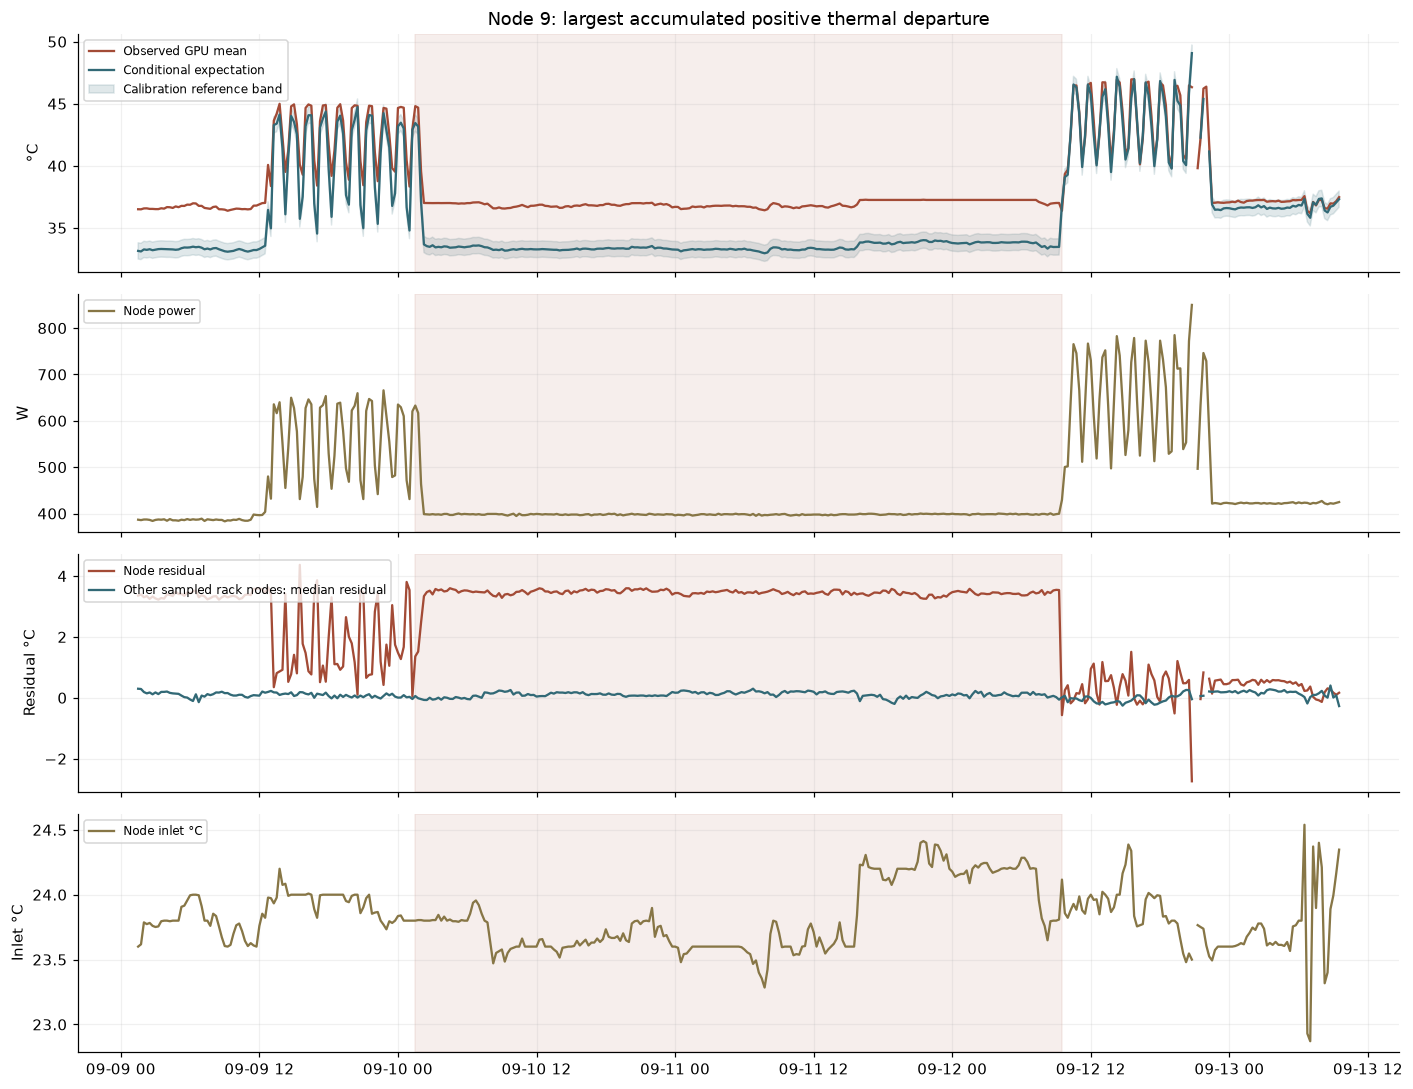

,gpu_temp,predicted_temp,thermal_residual,total_power_avg,ambient_avg,fan_rpm,value
count,416.00,414.00,414.00,416.00,416.00,416.00,412.0
mean,38.45,35.91,2.52,451.52,23.82,4446.42,0.0
std,2.99,4.01,1.39,102.85,0.25,68.77,0.0
min,36.18,32.95,-2.74,383.11,22.87,4409.17,0.0
25%,36.77,33.29,0.88,397.33,23.61,4416.39,0.0
50%,37.02,33.72,3.40,398.67,23.80,4418.75,0.0
75%,37.75,36.78,3.48,427.66,24.00,4423.33,0.0
max,46.97,49.08,4.37,850.00,24.54,5441.57,0.0


In [12]:
# Plot the strongest episode, including 24 h of context on either side.
if not episodes.empty:
    event = episodes.iloc[0]
    focus_node = int(event.node)
    window = panel[(panel.timestamp >= event.start-pd.Timedelta('1D')) & (panel.timestamp <= event.end+pd.Timedelta('1D'))]
    g = window[window.node==focus_node].set_index('timestamp')
    peer = window[(window.rack==focus_node//20)&(window.node!=focus_node)].groupby('timestamp')
    fig, axes = plt.subplots(4,1,figsize=(13,10),sharex=True)
    axes[0].plot(g.index,g.gpu_temp,label='Observed GPU mean',color=COLORS[0])
    axes[0].plot(g.index,g.predicted_temp,label='Conditional expectation',color=COLORS[1])
    axes[0].fill_between(g.index,(g.predicted_temp-g.thermal_threshold).to_numpy(float),
                        (g.predicted_temp+g.thermal_threshold).to_numpy(float),alpha=.15,color=COLORS[1],label='Calibration reference band')
    axes[0].set(ylabel='°C',title=f'Node {focus_node}: largest accumulated positive thermal departure')
    axes[1].plot(g.index,g.total_power_avg,color=COLORS[2],label='Node power');axes[1].set(ylabel='W')
    axes[2].plot(g.index,g.thermal_residual,label='Node residual',color=COLORS[0])
    peers = peer.thermal_residual.median()
    axes[2].plot(peers.index,peers,label='Other sampled rack nodes: median residual',color=COLORS[1]);axes[2].set(ylabel='Residual °C')
    axes[3].plot(g.index,g.ambient_avg,label='Node inlet °C',color=COLORS[2]);axes[3].set(ylabel='Inlet °C')
    for ax in axes:
        ax.axvspan(event.start,event.end,color=COLORS[0],alpha=.09);ax.legend(loc='upper left',fontsize=8)
    savefig('05_episode')
    display(g[['gpu_temp','predicted_temp','thermal_residual','total_power_avg','ambient_avg','fan_rpm','value']].describe().round(2))
else:
    focus_node = NODES[0]
    print('No positive thermal episode lasted one hour under the prespecified rule.')

## 6. Shared versus local changes and retrospective segmentation
Below: daily median residuals relative to each node's own training model. Shared
departures suggest a common influence but do not identify cooling, weather or scheduling
as the cause. A distinct single-node departure motivates local investigation.

Binary segmentation provides at most four candidate boundaries in the longest
uninterrupted daily-residual segment (minimum seven days). This deliberately forces
an exploratory partition; it is not evidence that four true regime changes exist.
It uses future context, so these boundaries are not online detection times.

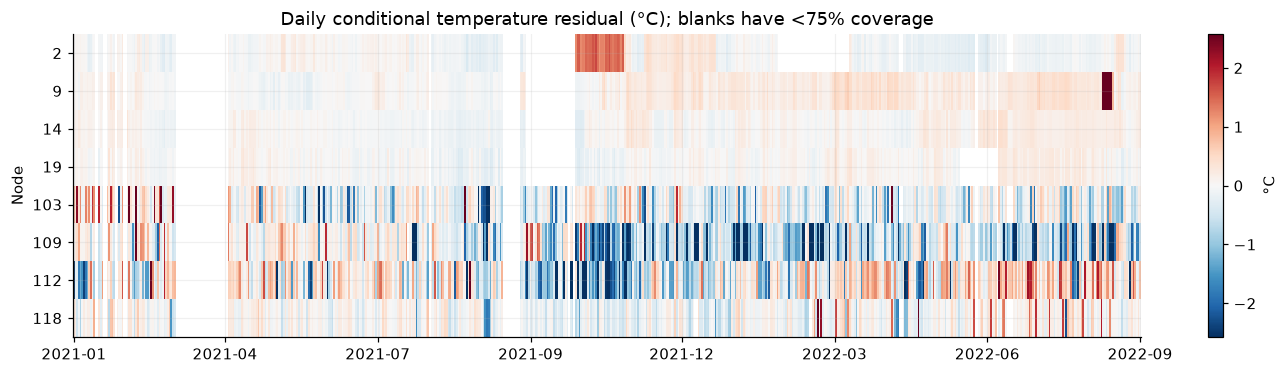

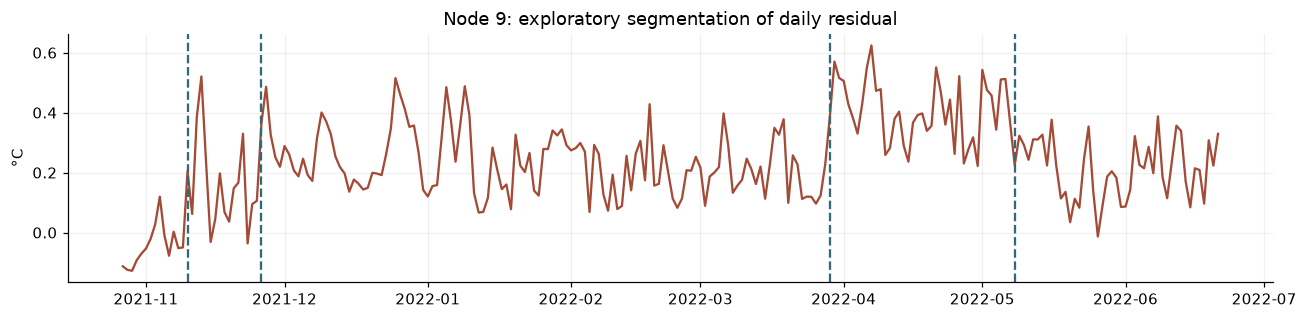

Candidate boundaries: ['2021-11-10 00:00:00+00:00', '2021-11-26 00:00:00+00:00', '2022-03-29 00:00:00+00:00', '2022-05-08 00:00:00+00:00']


In [13]:
daily_resid = panel.assign(day=panel.timestamp.dt.floor('D')).groupby(['day','node']).thermal_residual.agg(['median','count'])
daily_resid.loc[daily_resid['count'] < 72,'median'] = np.nan
heat = daily_resid['median'].unstack('node')
fig, ax = plt.subplots(figsize=(13,3.5))
vmax = max(1,float(np.nanquantile(np.abs(heat.to_numpy()),.98)))
im=ax.imshow(heat.T,aspect='auto',cmap='RdBu_r',vmin=-vmax,vmax=vmax,interpolation='nearest')
positions=np.linspace(0,len(heat)-1,8).astype(int)
ax.set(yticks=range(len(NODES)),yticklabels=heat.columns,xticks=positions,
       xticklabels=heat.index[positions].strftime('%Y-%m'),ylabel='Node',title='Daily conditional temperature residual (°C); blanks have <75% coverage')
fig.colorbar(im,ax=ax,label='°C');savefig('06_residual_heatmap')
s = heat[focus_node]
blocks = s.notna().ne(s.notna().shift(fill_value=False)).cumsum()
segments = [v for _,v in s.dropna().groupby(blocks[s.notna()])]
segment = max(segments,key=len)
assert len(segment)>=40
with threadpool_limits(limits=2):
    algo=rpt.Binseg(model='l2',min_size=7,jump=1).fit(segment.to_numpy())
    breaks=algo.predict(n_bkps=min(4,len(segment)//14-1))
fig,ax=plt.subplots(figsize=(12,3))
ax.plot(segment.index,segment,color=COLORS[0])
for b in breaks[:-1]: ax.axvline(segment.index[b],color=COLORS[1],ls='--')
ax.set(title=f'Node {focus_node}: exploratory segmentation of daily residual',ylabel='°C');savefig('07_segmentation')
boundaries=[str(segment.index[b]) for b in breaks[:-1]]
print('Candidate boundaries:',boundaries)

## 7. Sensitivity, interpretation and next experiment
We vary only the calibration quantile, without selecting a winner from test results.
This illustrates how much the alert volume depends on the threshold. A drift in the
conditional relationship can create many alerts even if the original calibration
threshold was appropriate. Nagios agreement is only one imperfect external check.

In [14]:
sensitivity=[]
for quantile in [.975,.99,.995]:
    for node in NODES:
        g=panel[panel.node==node]
        cal=g[(g.split=='calibration')&g.value.eq(0).fillna(False)]
        t=g[(g.split=='test')&g.thermal_score.notna()]
        cut=cal.thermal_score.quantile(quantile)
        sensitivity.append({'node':node,'calibration_quantile':quantile,'threshold_C':cut,
                            'test_alert_pct':100*(t.thermal_score>cut).mean()})
sensitivity=pd.DataFrame(sensitivity)
sensitivity.to_csv(OUT/'threshold_sensitivity.csv',index=False)
display(sensitivity.pivot(index='node',columns='calibration_quantile',values='test_alert_pct').round(2))

calibration_quantile,0.975,0.990,0.995
node,,,
2,0.06,0.05,0.04
9,8.22,5.07,4.15
14,2.02,1.50,1.31
19,1.05,0.46,0.31
103,0.64,0.17,0.03
109,0.29,0.12,0.07
112,1.34,0.85,0.58
118,5.30,2.71,1.74


## 8. Challenge the strongest finding: physical departure or model dependence?
The top episode was selected after inspecting scores. This is a **post-hoc diagnostic**,
not a second independent validation. Inspect raw sensors, training support and an
ablation that removes CPU power while retaining total power and inlet conditions.
CPU power can be informative in training yet change its relationship to GPU temperature
under another operating mode. A large residual may expose this model dependence.

,train_p01,train_median,train_p99,episode_median
total_power_avg,420.000,420.000,560.889,398.222
cpu_power,54.711,56.533,114.765,22.400
ambient_avg,23.378,24.858,26.478,23.722
gpu_temp,36.256,37.683,41.547,36.903
fan_rpm,4525.833,4533.056,4540.278,4418.056


node                                    9.000000
full_model_episode_mean_residual_C      3.439892
without_CPU_episode_mean_residual_C     0.861103
without_CPU_test_MAE_C                  0.327971
episode_CPU_below_train_p01_pct        99.107143
dtype: float64

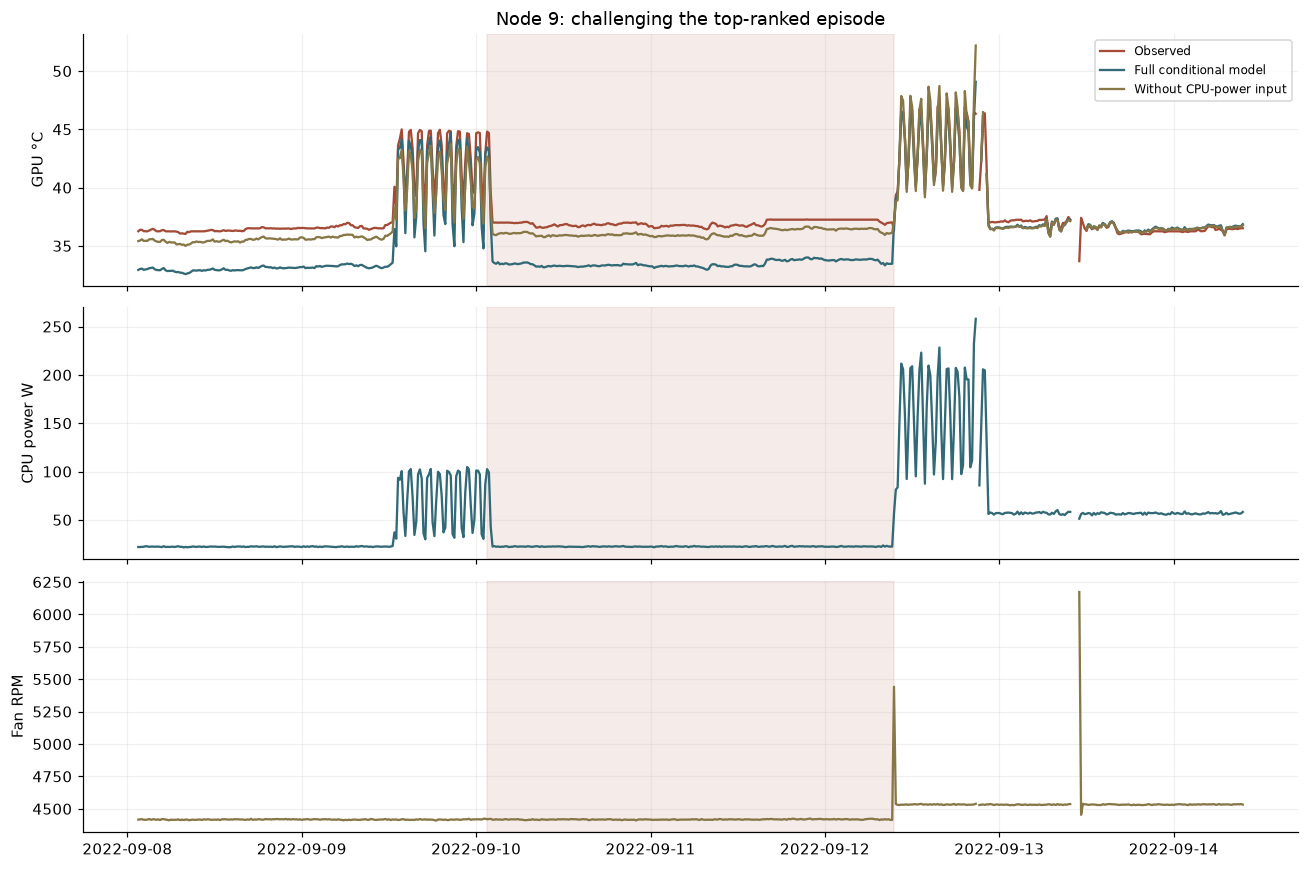

In [15]:
ablation_result = None
if not episodes.empty:
    event = episodes.iloc[0]
    node = int(event.node)
    g = panel[panel.node==node].copy()
    event_mask = (g.timestamp >= event.start) & (g.timestamp < event.end)
    train = (g.split=='train') & g.value.eq(0).fillna(False) & g[xcols+['thermal_lift']].notna().all(axis=1)
    diagnostic_cols = ['total_power_avg','cpu_power','ambient_avg','gpu_temp','fan_rpm']
    diagnostic = pd.DataFrame({
        'train_p01':g.loc[train,diagnostic_cols].quantile(.01),
        'train_median':g.loc[train,diagnostic_cols].median(),
        'train_p99':g.loc[train,diagnostic_cols].quantile(.99),
        'episode_median':g.loc[event_mask,diagnostic_cols].median()})
    display(diagnostic.round(3))
    diagnostic.to_csv(OUT/'episode_sensor_diagnostic.csv')
    reduced = [c for c in xcols if c!='cpu_power']
    alternate = make_pipeline(SplineTransformer(n_knots=5,degree=3,extrapolation='linear'),StandardScaler(),Ridge(alpha=100))
    with threadpool_limits(limits=2):
        alternate.fit(g.loc[train,reduced],g.loc[train,'thermal_lift'])
        valid=g[reduced+['gpu_temp']].notna().all(axis=1)
        g.loc[valid,'alternate_pred'] = alternate.predict(g.loc[valid,reduced])+g.loc[valid,'ambient_avg']
    em=event_mask & valid
    tm=(g.split=='test')&valid
    ablation_result={'node':node,'full_model_episode_mean_residual_C':float(g.loc[em,'thermal_residual'].mean()),
        'without_CPU_episode_mean_residual_C':float((g.loc[em,'gpu_temp']-g.loc[em,'alternate_pred']).mean()),
        'without_CPU_test_MAE_C':float(mean_absolute_error(g.loc[tm,'gpu_temp'],g.loc[tm,'alternate_pred'])),
        'episode_CPU_below_train_p01_pct':float(100*(g.loc[em,'cpu_power']<diagnostic.loc['cpu_power','train_p01']).mean())}
    display(pd.Series(ablation_result))
    (OUT/'episode_ablation.json').write_text(json.dumps(ablation_result,indent=2))
    w=g[(g.timestamp>=event.start-pd.Timedelta('2D'))&(g.timestamp<=event.end+pd.Timedelta('2D'))]
    fig,axes=plt.subplots(3,1,figsize=(12,8),sharex=True)
    axes[0].plot(w.timestamp,w.gpu_temp,label='Observed',color=COLORS[0])
    axes[0].plot(w.timestamp,w.predicted_temp,label='Full conditional model',color=COLORS[1])
    axes[0].plot(w.timestamp,w.alternate_pred,label='Without CPU-power input',color=COLORS[2])
    axes[0].set(ylabel='GPU °C',title=f'Node {node}: challenging the top-ranked episode');axes[0].legend(fontsize=8)
    axes[1].plot(w.timestamp,w.cpu_power,color=COLORS[1]);axes[1].set(ylabel='CPU power W')
    axes[2].plot(w.timestamp,w.fan_rpm,color=COLORS[2]);axes[2].set(ylabel='Fan RPM')
    for ax in axes:ax.axvspan(event.start,event.end,color=COLORS[0],alpha=.1)
    savefig('08_episode_ablation')

In [16]:
summary = {'source_rows':int(audit.rows.sum()), 'audited_nodes':len(audit), 'modeled_nodes':NODES,
    'model_period':[str(START),str(END)], 'thermal_MAE_mean_C':float(fit_metrics.test_MAE_C.mean()),
    'linear_MAE_mean_C':float(fit_metrics.linear_test_MAE_C.mean()), 'thermal_baseline_MAE_mean_C':float(fit_metrics.inlet_plus_train_median_MAE_C.mean()),
    'positive_episodes_at_least_1h':len(episodes),
    'comparison_macro_means':metrics.groupby('model')[['ROC_AUC','average_precision','precision','recall','state0_alert_rate']].mean().to_dict('index'),
    'top_episode':json.loads(episodes.head(1).to_json(orient='records',date_format='iso')) if not episodes.empty else [],
    'episode_ablation':ablation_result, 'segmentation_node':focus_node,'candidate_boundaries':boundaries}
(OUT/'summary.json').write_text(json.dumps(summary,indent=2,allow_nan=False))
# Persist narrow results for follow-up analysis; the larger scored panel stays local.
panel[['timestamp','node','rack','split','value','total_power_avg','gpu_temp','ambient_avg',
       'predicted_temp','thermal_residual','thermal_threshold','thermal_score','pca_score','ae_score']].to_parquet(DATA/'scored_panel.parquet',index=False)
display(Markdown(f'''**Observed result:** the thermal model's mean per-node test MAE is
**{summary['thermal_MAE_mean_C']:.2f} °C**, compared with **{summary['thermal_baseline_MAE_mean_C']:.2f} °C**
for inlet temperature plus each node's training median thermal lift.
A stronger linear regression using the same inputs has mean per-node MAE **{summary['linear_MAE_mean_C']:.2f} °C**.
There are **{len(episodes)}** positive-residual episodes lasting at least an hour under the fixed 99% calibration rule.
These counts are model-dependent investigation candidates, not confirmed faults.'''))

**Observed result:** the thermal model's mean per-node test MAE is
**0.60 °C**, compared with **3.27 °C**
for inlet temperature plus each node's training median thermal lift.
A stronger linear regression using the same inputs has mean per-node MAE **0.56 °C**.
There are **86** positive-residual episodes lasting at least an hour under the fixed 99% calibration rule.
These counts are model-dependent investigation candidates, not confirmed faults.

### What this study can and cannot establish
- It measures departures from historical sensor relationships on eight nodes in two convenience-selected racks.
- Complete-case scores omit periods with insufficient telemetry. Missingness deserves its own detector.
- A model trained in 2021 can be wrong in 2022 because of benign changes in workload mix, maintenance,
  fan control or hardware. A large residual is not a causal diagnosis.
- Temperature is averaged across four GPUs; a single-device issue may be diluted. Per-GPU models
  and within-node contrasts are a natural follow-up.
- The autoencoder is a modest baseline; its results do not establish the value or failure of all
  neural models. No VAE or hyperparameter sweep has been run.
- A broader study should join job/GPU-utilization and detailed Nagios descriptions, obtain intervention
  logs if possible, repeat across racks, and assess event-level precision and detection delay.
- A Desk card could show the episode, conditional baseline, neighboring-node context, sensor coverage
  and contributing measurements. It should say **thermal departure**, not **wasted energy** or **fault**.

## 9. Main interpretation of the executed experiment
The most useful result is the model-dependence check, not the number of flags.
In the top-ranked node-9 episode, the full model reports an average +3.44 °C residual,
but removing CPU power reduces it to +0.86 °C. About 99% of episode CPU-power values
are below the training 1st percentile. This suggests an unfamiliar operating regime
and model dependence; it does not establish overheating. Removing CPU power is a
post-hoc diagnostic, not a validated replacement model.

The simple models have poor agreement with the broad Nagios states, and the capped
autoencoder still reports a convergence warning at 300 epochs. Its result is a
preliminary baseline, not a fully optimized neural benchmark.

**Promising next question:** which power–temperature relationships remain stable
across operating modes, and which apparent anomalies disappear once those modes
are represented? A useful next experiment joins workload/utilization data and models
individual GPUs, while keeping the episode explanations and data-coverage checks.

The stronger baseline changes the model-selection conclusion: **linear regression has mean per-node held-out MAE 0.56 °C, versus 0.60 °C for the spline model and 3.27 °C for the inlet-plus-offset baseline**. On this sample, extra spline flexibility does not improve the macro-average error. The promising result is conditional modeling itself; there is no demonstrated need for a VAE yet. These are eight-node averages, not an estimate of performance over the whole machine.